<a href="https://colab.research.google.com/github/Arjun-08/Incremental-Learning-and-Catastrophic-Forgetting/blob/main/incremental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import copy
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Separate train (augmented) / eval (deterministic) transforms.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
DATA_PATH = "./oxford_pet"

base_train = OxfordIIITPet(root=DATA_PATH, split="trainval", download=True)
base_test = OxfordIIITPet(root=DATA_PATH, split="test", download=True)

100%|██████████| 792M/792M [00:30<00:00, 25.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


In [7]:
classes = base_train.classes
num_classes_total = len(classes)
print(f"Total classes: {num_classes_total}")

Total classes: 37


In [8]:
def get_targets(dataset):
    """Fast label lookup (avoids decoding every image just to read its class)."""
    if hasattr(dataset, "_labels"):
        return np.array(dataset._labels)
    return np.array([dataset[i][1] for i in range(len(dataset))])  # fallback


train_targets = get_targets(base_train)
test_targets = get_targets(base_test)

In [9]:
class TransformSubset(Dataset):
    """Wraps a base (transform-less) dataset + explicit indices, applying `transform` lazily."""

    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.base_dataset[self.indices[i]]
        return self.transform(img), label

In [10]:
# Class split: first 20 classes = "old" task, remaining 17 = "new" task
NUM_OLD_CLASSES = 20
old_class_ids = list(range(NUM_OLD_CLASSES))
new_class_ids = list(range(NUM_OLD_CLASSES, num_classes_total))

In [11]:
def indices_for_classes(targets, class_ids):
    return np.where(np.isin(targets, class_ids))[0].tolist()


train_old_idx = indices_for_classes(train_targets, old_class_ids)
test_old_idx = indices_for_classes(test_targets, old_class_ids)
train_new_idx = indices_for_classes(train_targets, new_class_ids)
test_new_idx = indices_for_classes(test_targets, new_class_ids)

train_old_ds = TransformSubset(base_train, train_old_idx, train_transform)
test_old_ds = TransformSubset(base_test, test_old_idx, eval_transform)
train_new_ds = TransformSubset(base_train, train_new_idx, train_transform)
test_new_ds = TransformSubset(base_test, test_new_idx, eval_transform)
full_test_ds = TransformSubset(base_test, list(range(len(base_test))), eval_transform)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_old_loader = DataLoader(train_old_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
test_old_loader = DataLoader(test_old_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
train_new_loader = DataLoader(train_new_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
test_new_loader = DataLoader(test_new_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
full_test_loader = DataLoader(full_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)

print(f"Old-task train/test sizes: {len(train_old_ds)}/{len(test_old_ds)}")
print(f"New-task train/test sizes: {len(train_new_ds)}/{len(test_new_ds)}")

Old-task train/test sizes: 1985/1981
New-task train/test sizes: 1695/1688


In [12]:
class BackboneResNet(nn.Module):
    def __init__(self, num_classes, arch="resnet18", pretrained=False):
        super().__init__()
        weights = "IMAGENET1K_V1" if pretrained else None
        base = getattr(torchvision.models, arch)(weights=weights)
        in_features = base.fc.in_features
        base.fc = nn.Identity()
        self.feature_extractor = base           # -> [B, in_features]
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.classifier(self.feature_extractor(x))

In [13]:
PRETRAINED = False
ARCH = "resnet18"

model = BackboneResNet(num_classes=NUM_OLD_CLASSES, arch=ARCH, pretrained=PRETRAINED).to(device)

In [14]:
def evaluate(net, loader):
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = net(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

In [15]:
def train_one_task(net, train_loader, val_loader, num_epochs, lr,
                    weight_decay=5e-4, label_smoothing=0.1):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9,
                           weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_acc, best_state = 0.0, copy.deepcopy(net.state_dict())

    for epoch in range(num_epochs):
        net.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        scheduler.step()

        train_acc = 100.0 * correct / total
        val_acc = evaluate(net, val_loader) if val_loader is not None else float("nan")
        print(f"Epoch [{epoch + 1}/{num_epochs}] loss={running_loss / total:.4f} "
              f"train_acc={train_acc:.2f}% val_acc={val_acc:.2f}%")

        if val_loader is not None and val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(net.state_dict())

    if val_loader is not None:
        net.load_state_dict(best_state)
        print(f"Restored best checkpoint (val_acc={best_acc:.2f}%)")
    return net

In [16]:
def expand_classifier(base_model, new_num_classes):
    new_model = copy.deepcopy(base_model)
    in_features = new_model.classifier.in_features
    old_num_classes = new_model.classifier.out_features
    new_classifier = nn.Linear(in_features, new_num_classes).to(device)
    with torch.no_grad():
        new_classifier.weight[:old_num_classes] = new_model.classifier.weight
        new_classifier.bias[:old_num_classes] = new_model.classifier.bias
    new_model.classifier = new_classifier
    return new_model

In [17]:
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

In [18]:
print("\n===== base model on 20 classes =====")
model = train_one_task(model, train_old_loader, test_old_loader, num_epochs=30, lr=0.01)


===== base model on 20 classes =====
Epoch [1/30] loss=3.0445 train_acc=7.20% val_acc=5.05%
Epoch [2/30] loss=2.9654 train_acc=13.30% val_acc=5.10%
Epoch [3/30] loss=2.7958 train_acc=19.09% val_acc=5.10%
Epoch [4/30] loss=2.6680 train_acc=24.69% val_acc=6.31%
Epoch [5/30] loss=2.5502 train_acc=27.00% val_acc=11.86%
Epoch [6/30] loss=2.4379 train_acc=31.59% val_acc=7.07%
Epoch [7/30] loss=2.3391 train_acc=34.46% val_acc=12.92%
Epoch [8/30] loss=2.2431 train_acc=37.23% val_acc=10.50%
Epoch [9/30] loss=2.1702 train_acc=39.65% val_acc=23.22%
Epoch [10/30] loss=2.1039 train_acc=42.57% val_acc=19.28%
Epoch [11/30] loss=1.9785 train_acc=48.01% val_acc=26.40%
Epoch [12/30] loss=1.9046 train_acc=50.18% val_acc=34.88%
Epoch [13/30] loss=1.8319 train_acc=53.20% val_acc=33.87%
Epoch [14/30] loss=1.7386 train_acc=56.57% val_acc=27.06%
Epoch [15/30] loss=1.6686 train_acc=57.83% val_acc=28.37%
Epoch [16/30] loss=1.5936 train_acc=62.07% val_acc=33.42%
Epoch [17/30] loss=1.4965 train_acc=65.74% val_ac

In [19]:
base_test_acc = evaluate(model, test_old_loader)
print(f" Base model test accuracy on 20 classes: {base_test_acc:.2f}%")

 Base model test accuracy on 20 classes: 49.47%


In [20]:
F0 = copy.deepcopy(model.feature_extractor).to(device).eval()
G0 = copy.deepcopy(model.classifier).to(device).eval()
for p in F0.parameters():
    p.requires_grad = False
for p in G0.parameters():
    p.requires_grad = False

In [21]:
# Expand classifier to 37 classes, naive fine-tune on new 17 classes

print("\n===== naive fine-tuning on 17 new classes =====")
model_naive = expand_classifier(model, num_classes_total)
model_naive = train_one_task(model_naive, train_new_loader, test_new_loader, num_epochs=15, lr=0.005)

total_acc_naive = evaluate(model_naive, full_test_loader)
old_acc_naive = evaluate(model_naive, test_old_loader)
new_acc_naive = evaluate(model_naive, test_new_loader)

print(f" Total accuracy (37 classes): {total_acc_naive:.2f}%")
print(f" Old-20 accuracy: {old_acc_naive:.2f}% (was {base_test_acc:.2f}% before fine-tuning)")
print(f" New-17 accuracy: {new_acc_naive:.2f}%")
print(f" Forgetting on old classes: {base_test_acc - old_acc_naive:.2f} points")


===== naive fine-tuning on 17 new classes =====
Epoch [1/15] loss=2.9528 train_acc=20.71% val_acc=31.52%
Epoch [2/15] loss=2.2840 train_acc=42.95% val_acc=35.72%
Epoch [3/15] loss=2.0395 train_acc=50.50% val_acc=37.26%
Epoch [4/15] loss=1.9205 train_acc=55.40% val_acc=39.04%
Epoch [5/15] loss=1.7726 train_acc=60.24% val_acc=46.03%
Epoch [6/15] loss=1.6830 train_acc=64.37% val_acc=49.70%
Epoch [7/15] loss=1.5853 train_acc=68.14% val_acc=48.34%
Epoch [8/15] loss=1.5017 train_acc=72.74% val_acc=48.93%
Epoch [9/15] loss=1.4048 train_acc=75.93% val_acc=50.36%
Epoch [10/15] loss=1.3510 train_acc=77.82% val_acc=53.73%
Epoch [11/15] loss=1.2997 train_acc=80.18% val_acc=58.12%
Epoch [12/15] loss=1.2624 train_acc=82.12% val_acc=56.99%
Epoch [13/15] loss=1.2279 train_acc=83.83% val_acc=58.23%
Epoch [14/15] loss=1.1986 train_acc=85.43% val_acc=59.60%
Epoch [15/15] loss=1.2087 train_acc=84.25% val_acc=59.30%
Restored best checkpoint (val_acc=59.60%)
 Total accuracy (37 classes): 27.42%
 Old-20 acc

In [30]:
print("\n===== exemplar replay + knowledge distillation =====")

NUM_EXEMPLARS_PER_CLASS = 5


def select_herding_exemplars(feature_extractor, dataset, targets, class_ids, k):
    feature_extractor.eval()
    selected = []
    with torch.no_grad():
        for c in class_ids:
            cls_idx = np.where(targets == c)[0]
            imgs = torch.stack([eval_transform(dataset[i][0]) for i in cls_idx]).to(device)
            feats = F.normalize(feature_extractor(imgs), dim=1)
            class_mean = feats.mean(dim=0, keepdim=True)

            chosen, running_sum = [], torch.zeros_like(class_mean)
            remaining = list(range(len(cls_idx)))
            for _ in range(min(k, len(cls_idx))):
                candidate_means = (running_sum + feats[remaining]) / (len(chosen) + 1)
                dists = torch.norm(candidate_means - class_mean, dim=1)
                best_local = torch.argmin(dists).item()
                best = remaining[best_local]
                chosen.append(best)
                running_sum += feats[best].unsqueeze(0)
                remaining.remove(best)
            selected.extend(cls_idx[chosen].tolist())
    return selected


===== exemplar replay + knowledge distillation =====


In [28]:
exemplar_indices = select_herding_exemplars(F0, base_train, train_targets, old_class_ids,
                                             NUM_EXEMPLARS_PER_CLASS)
exemplar_train_ds = TransformSubset(base_train, exemplar_indices, train_transform)
exemplar_loader = DataLoader(exemplar_train_ds,
                              batch_size=min(BATCH_SIZE, len(exemplar_train_ds)),
                              shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Selected {len(exemplar_indices)} exemplars ({NUM_EXEMPLARS_PER_CLASS}/old class).")

Selected 100 exemplars (5/old class).


In [29]:
def finetune_with_distillation(net, F0, G0, new_loader, exemplar_loader,
                                num_epochs, lr, alpha=1.0, temperature=2.0, weight_decay=5e-4):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9,
                           weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    exemplar_iter = infinite_loader(exemplar_loader)

    for epoch in range(num_epochs):
        net.train()
        running_cls, running_kd, correct, total = 0.0, 0.0, 0, 0

        for images, labels in new_loader:
            images, labels = images.to(device), labels.to(device)
            e_images, e_labels = next(exemplar_iter)
            e_images, e_labels = e_images.to(device), e_labels.to(device)

            combined_images = torch.cat([images, e_images], dim=0)
            combined_labels = torch.cat([labels, e_labels], dim=0)
            outputs = net(combined_images)
            cls_loss = criterion(outputs, combined_labels)

            student_logits_old = outputs[labels.size(0):, :NUM_OLD_CLASSES]
            with torch.no_grad():
                teacher_logits = G0(F0(e_images))

            kd_loss = F.kl_div(
                F.log_softmax(student_logits_old / temperature, dim=1),
                F.softmax(teacher_logits / temperature, dim=1),
                reduction="batchmean",
            ) * (temperature ** 2)

            loss = cls_loss + alpha * kd_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_cls += cls_loss.item() * combined_labels.size(0)
            running_kd += kd_loss.item() * e_labels.size(0)
            correct += (outputs.argmax(1) == combined_labels).sum().item()
            total += combined_labels.size(0)
        scheduler.step()

        print(f"Epoch [{epoch + 1}/{num_epochs}] cls_loss={running_cls / total:.4f} "
              f"kd_loss={running_kd / total:.4f} acc={100.0 * correct / total:.2f}%")

    return net


In [25]:
model_distilled = expand_classifier(model, num_classes_total)  # fresh start, same as step 2
model_distilled = finetune_with_distillation(
    model_distilled, F0, G0, train_new_loader, exemplar_loader,
    num_epochs=15, lr=0.005, alpha=1.0, temperature=2.0,
)

total_acc_kd = evaluate(model_distilled, full_test_loader)
old_acc_kd = evaluate(model_distilled, test_old_loader)
new_acc_kd = evaluate(model_distilled, test_new_loader)

print(f"\n[STEP 3] Total accuracy (37 classes): {total_acc_kd:.2f}%")
print(f"[STEP 3] Old-20 accuracy: {old_acc_kd:.2f}%")
print(f"[STEP 3] New-17 accuracy: {new_acc_kd:.2f}%")

Epoch [1/15] cls_loss=2.3732 kd_loss=0.0872 acc=47.64%
Epoch [2/15] cls_loss=1.9809 kd_loss=0.0916 acc=59.37%
Epoch [3/15] cls_loss=1.8342 kd_loss=0.0802 acc=65.97%
Epoch [4/15] cls_loss=1.7268 kd_loss=0.0731 acc=70.36%
Epoch [5/15] cls_loss=1.6614 kd_loss=0.0744 acc=72.65%
Epoch [6/15] cls_loss=1.5951 kd_loss=0.0668 acc=75.19%
Epoch [7/15] cls_loss=1.5449 kd_loss=0.0649 acc=76.94%
Epoch [8/15] cls_loss=1.4848 kd_loss=0.0600 acc=78.49%
Epoch [9/15] cls_loss=1.4465 kd_loss=0.0562 acc=80.41%
Epoch [10/15] cls_loss=1.4117 kd_loss=0.0556 acc=81.73%
Epoch [11/15] cls_loss=1.3829 kd_loss=0.0501 acc=82.56%
Epoch [12/15] cls_loss=1.3647 kd_loss=0.0473 acc=83.76%
Epoch [13/15] cls_loss=1.3403 kd_loss=0.0465 acc=84.54%
Epoch [14/15] cls_loss=1.3374 kd_loss=0.0458 acc=84.27%
Epoch [15/15] cls_loss=1.3259 kd_loss=0.0464 acc=84.87%

[STEP 3] Total accuracy (37 classes): 33.47%
[STEP 3] Old-20 accuracy: 17.31%
[STEP 3] New-17 accuracy: 52.43%



================= SUMMARY =================
Metric                             No Distillation   With Distillation
Total accuracy (37 classes)                 27.42%              33.47%
Old-20 classes accuracy                      0.00%              17.31%
New-17 classes accuracy                     59.60%              52.43%
Forgetting vs. base (old-20)               49.47pt             32.16pt


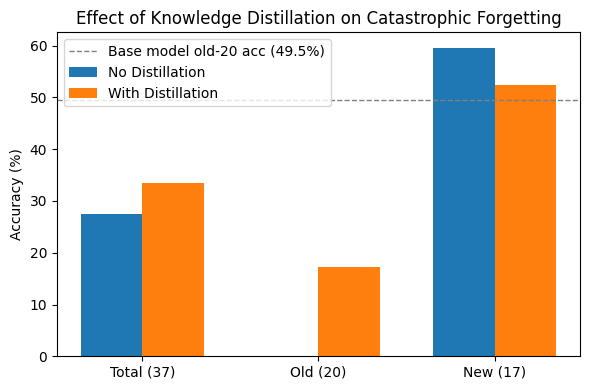

In [26]:
print("\n================= SUMMARY =================")
print(f"{'Metric':32s}{'No Distillation':>18s}{'With Distillation':>20s}")
print(f"{'Total accuracy (37 classes)':32s}{total_acc_naive:>17.2f}%{total_acc_kd:>19.2f}%")
print(f"{'Old-20 classes accuracy':32s}{old_acc_naive:>17.2f}%{old_acc_kd:>19.2f}%")
print(f"{'New-17 classes accuracy':32s}{new_acc_naive:>17.2f}%{new_acc_kd:>19.2f}%")
print(f"{'Forgetting vs. base (old-20)':32s}{base_test_acc - old_acc_naive:>16.2f}pt"
      f"{base_test_acc - old_acc_kd:>18.2f}pt")

labels_ = ["Total (37)", "Old (20)", "New (17)"]
naive_vals = [total_acc_naive, old_acc_naive, new_acc_naive]
kd_vals = [total_acc_kd, old_acc_kd, new_acc_kd]

x = np.arange(len(labels_))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, naive_vals, width, label="No Distillation")
ax.bar(x + width / 2, kd_vals, width, label="With Distillation")
ax.axhline(base_test_acc, color="gray", linestyle="--", linewidth=1,
           label=f"Base model old-20 acc ({base_test_acc:.1f}%)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Effect of Knowledge Distillation on Catastrophic Forgetting")
ax.set_xticks(x)
ax.set_xticklabels(labels_)
ax.legend()
plt.tight_layout()
plt.savefig("distillation_comparison.png", dpi=150)
plt.show()

In [27]:
print("hello")

hello
